# Fáze 1: Načtení dat a analýza
Tento notebook načítá Olist Brazilian E-Commerce dataset

In [1]:
import sys
import logging
import warnings
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

_PROJECT_ROOT = Path(os.path.abspath("")).parent if Path(os.path.abspath("")).name == "notebooks" else Path(os.path.abspath(""))
os.chdir(_PROJECT_ROOT)
sys.path.insert(0, str(_PROJECT_ROOT))

print(f"CWD: {os.getcwd()}")

from src.data_preparation import (
    load_raw_tables,
    translate_categories,
    filter_delivered_orders,
    merge_orders_products,
    compute_turnover_metrics,
    compute_avg_review_score,
    build_products_clean,
)

logging.basicConfig(level=logging.INFO, format="%(name)s - %(message)s")
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

RESULTS_DIR = "results/phase1_eda"
os.makedirs(RESULTS_DIR, exist_ok=True)

CWD: C:\Users\kosar\Desktop\bakalarka_git\bakalarka


## 1. Načtení a propojení dat

In [2]:
# Načtení všech tabulek
tables = load_raw_tables()
products_raw = tables["products"]
orders_raw = tables["orders"]
order_items = tables["order_items"]
sellers = tables["sellers"]
reviews = tables["reviews"]
translation = tables["category_translation"]

print(f"Produkty: {len(products_raw):,}")
print(f"Objednávky: {len(orders_raw):,}")
print(f"Položky objednávek: {len(order_items):,}")
print(f"Prodejci: {len(sellers):,}")
print(f"Recenze: {len(reviews):,}")

src.data_preparation - Loaded products                   shape=(32951, 9)
src.data_preparation - Loaded order_items                shape=(112650, 7)
src.data_preparation - Loaded orders                     shape=(99441, 8)
src.data_preparation - Loaded sellers                    shape=(3095, 4)
src.data_preparation - Loaded reviews                    shape=(99224, 7)
src.data_preparation - Loaded category_translation       shape=(71, 2)


Produkty: 32,951
Objednávky: 99,441
Položky objednávek: 112,650
Prodejci: 3,095
Recenze: 99,224


### Přehled počtů v každém kroku pipeline

In [3]:
products = translate_categories(products_raw, translation)
orders = filter_delivered_orders(orders_raw)
status_counts = orders_raw["order_status"].value_counts()
print("Distribuce stavů objednávek:")
print(status_counts)
print(f"\nPonecháno {len(orders):,} delivered objednávek z {len(orders_raw):,} ({len(orders)/len(orders_raw)*100:.1f}%)")

src.data_preparation - Categories still missing after manual map: 610 → filling with 'unknown'
src.data_preparation - Filtered delivered orders: 99441 → 96478


Distribuce stavů objednávek:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Ponecháno 96,478 delivered objednávek z 99,441 (97.0%)


In [4]:
merged = merge_orders_products(orders, order_items, products)
turnover = compute_turnover_metrics(merged)
review_scores = compute_avg_review_score(reviews, order_items)

df = build_products_clean()
print(f"\nFinální dataset: {df.shape[0]:,} produktů × {df.shape[1]} sloupců")
print(f"Sloupce: {df.columns.tolist()}")

src.data_preparation - After merge with order_items: 110197 rows
src.data_preparation - After merge with products: 110197 rows
src.data_preparation - Turnover metrics computed for 32216 products
src.data_preparation - Avg review score computed for 32789 products
src.data_preparation - Loaded products                   shape=(32951, 9)
src.data_preparation - Loaded order_items                shape=(112650, 7)
src.data_preparation - Loaded orders                     shape=(99441, 8)
src.data_preparation - Loaded sellers                    shape=(3095, 4)
src.data_preparation - Loaded reviews                    shape=(99224, 7)
src.data_preparation - Loaded category_translation       shape=(71, 2)
src.data_preparation - Categories still missing after manual map: 610 → filling with 'unknown'
src.data_preparation - Filtered delivered orders: 99441 → 96478
src.data_preparation - After merge with order_items: 110197 rows
src.data_preparation - After merge with products: 110197 rows
src.data_p


Finální dataset: 32,951 produktů × 16 sloupců
Sloupce: ['product_id', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'order_count', 'total_quantity', 'avg_price', 'avg_freight', 'first_order_date', 'last_order_date', 'avg_review_score']


## 2. Základní statistiky

In [5]:
df.describe().round(2)

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_count,total_quantity,avg_price,avg_freight,avg_review_score
count,32341.00,32341.00,32341.00,32949.00,32949.00,32949.00,32949.00,32216.00,32216.00,32216.00,32216.00,32789.00
mean,48.48,771.50,2.19,2276.47,30.82,16.94,23.20,3.11,3.42,144.39,21.14,4.05
std,10.25,635.12,1.74,4282.04,16.91,13.64,12.08,9.41,10.58,246.47,17.93,1.21
min,5.00,4.00,1.00,0.00,7.00,2.00,6.00,1.00,1.00,0.85,0.01,1.00
25%,42.00,339.00,1.00,300.00,18.00,8.00,15.00,1.00,1.00,39.90,13.60,3.61
50%,51.00,595.00,1.00,700.00,25.00,13.00,20.00,1.00,1.00,79.00,16.71,4.50
75%,57.00,972.00,3.00,1900.00,38.00,21.00,30.00,2.00,3.00,153.00,21.79,5.00
max,76.00,3992.00,20.00,40425.00,105.00,105.00,118.00,456.00,520.00,6735.00,409.68,5.00


In [6]:
print("Chybějící hodnoty:")
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"\nPočet produktů s kompletními daty: {df.dropna().shape[0]:,} z {df.shape[0]:,}")

Chybějící hodnoty:
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
order_count                   735
total_quantity                735
avg_price                     735
avg_freight                   735
first_order_date              735
last_order_date               735
avg_review_score              162
dtype: int64

Počet produktů s kompletními daty: 31,494 z 32,951


## 3. Distribuce fyzických atributů

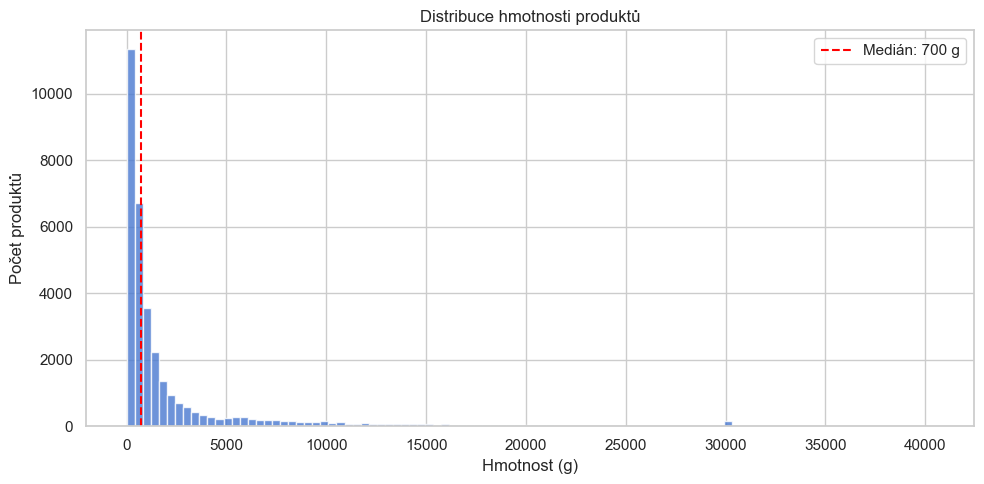

Hmotnost — Min: 0, Medián: 700, Mean: 2276, Max: 40425


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
weight_data = df["product_weight_g"].dropna()
ax.hist(weight_data, bins=100, edgecolor="white", alpha=0.8)
ax.set_xlabel("Hmotnost (g)")
ax.set_ylabel("Počet produktů")
ax.set_title("Distribuce hmotnosti produktů")
ax.axvline(weight_data.median(), color="red", linestyle="--", label=f"Medián: {weight_data.median():.0f} g")
ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/eda_weight_distribution.png", bbox_inches="tight")
plt.show()

print(f"Hmotnost — Min: {weight_data.min():.0f}, Medián: {weight_data.median():.0f}, Mean: {weight_data.mean():.0f}, Max: {weight_data.max():.0f}")

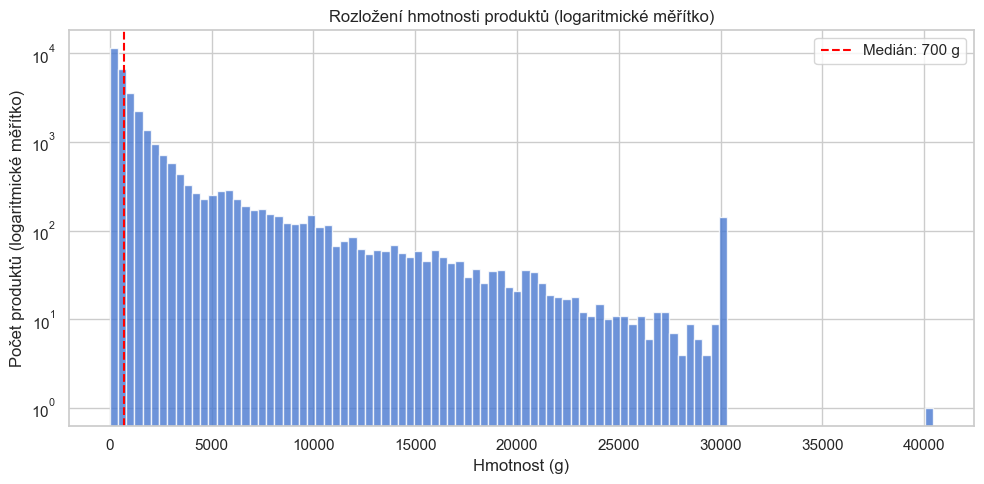

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(weight_data, bins=100, edgecolor="white", alpha=0.8)
ax.set_xlabel("Hmotnost (g)")
ax.set_ylabel("Počet produktů (logaritmické měřítko)")
ax.set_title("Rozložení hmotnosti produktů (logaritmické měřítko)")
ax.set_yscale("log")
ax.axvline(weight_data.median(), color="red", linestyle="--", label=f"Medián: {weight_data.median():.0f} g")
ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/eda_weight_log_distribution.png", bbox_inches="tight")
plt.show()

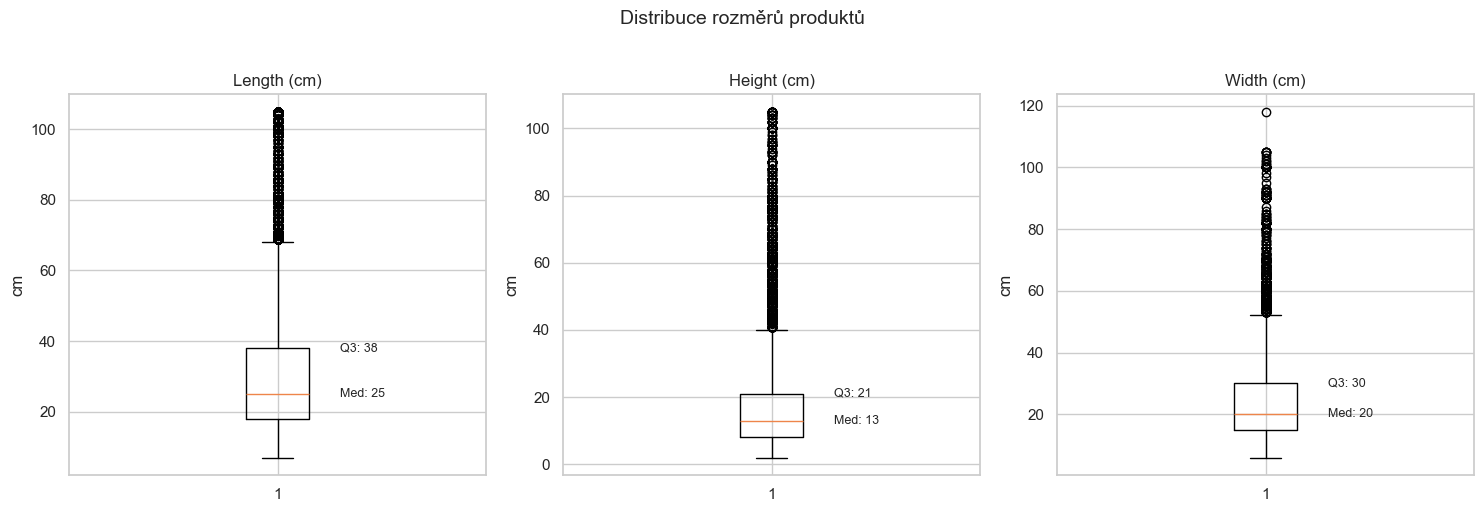

In [9]:
dims = ["product_length_cm", "product_height_cm", "product_width_cm"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, dims):
    data = df[col].dropna()
    ax.boxplot(data, vert=True)
    ax.set_title(col.replace("product_", "").replace("_cm", " (cm)").capitalize())
    ax.set_ylabel("cm")
    ax.text(1.15, data.median(), f"Med: {data.median():.0f}", va="center", fontsize=9)
    ax.text(1.15, data.quantile(0.75), f"Q3: {data.quantile(0.75):.0f}", va="center", fontsize=9)

plt.suptitle("Distribuce rozměrů produktů", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/eda_dimensions_boxplot.png", bbox_inches="tight")
plt.show()

## 4. Kategorie produktů

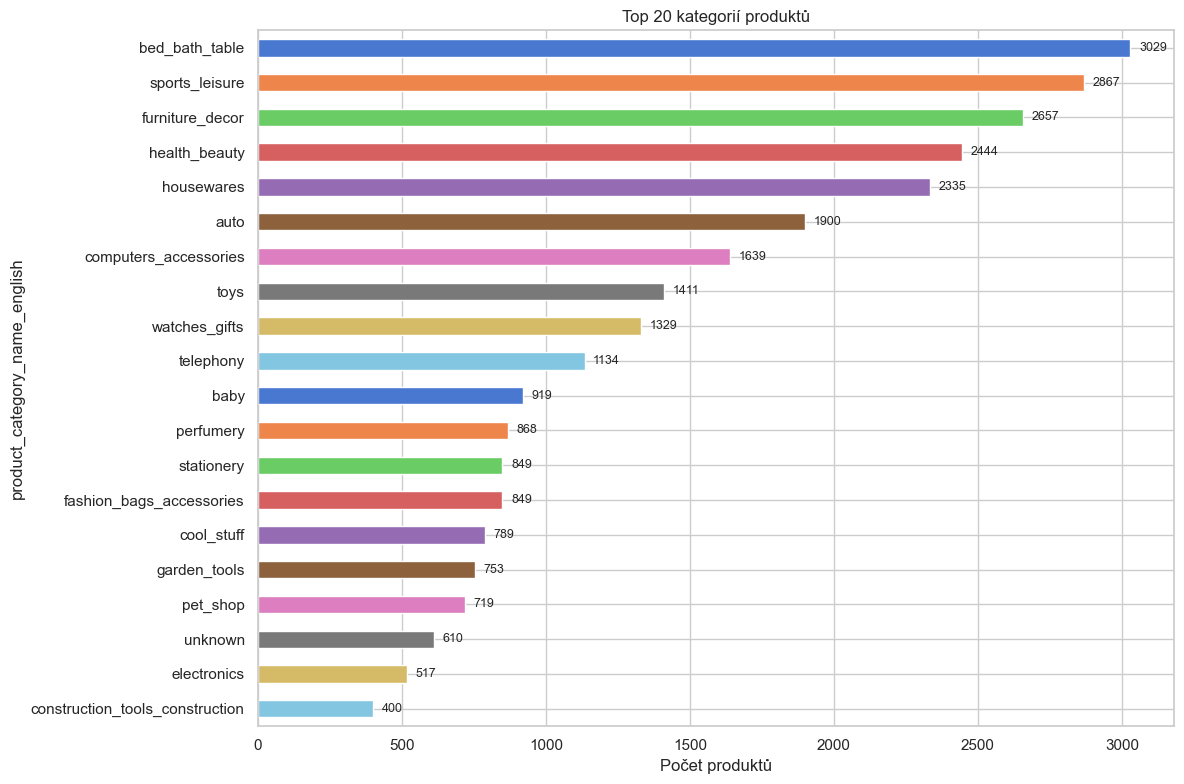

Celkový počet kategorií: 74


In [10]:
top20 = df["product_category_name_english"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 8))
top20.plot(kind="barh", ax=ax, color=sns.color_palette("muted", len(top20)))
ax.set_xlabel("Počet produktů")
ax.set_title("Top 20 kategorií produktů")
ax.invert_yaxis()

for i, v in enumerate(top20.values):
    ax.text(v + 30, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/eda_top20_categories.png", bbox_inches="tight")
plt.show()

print(f"Celkový počet kategorií: {df['product_category_name_english'].nunique()}")

## 5. Obrátkovost (turnover)

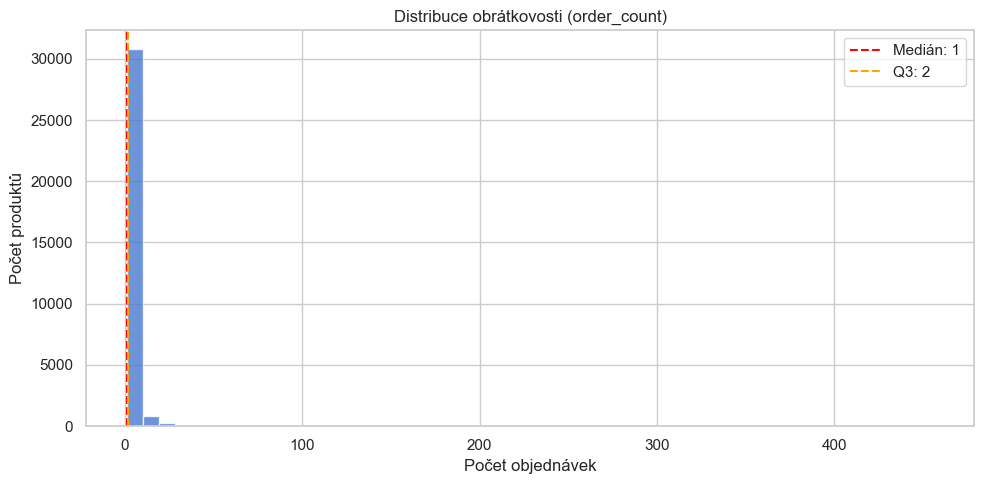

Obrátkovost — Min: 1, Medián: 1, Mean: 3.1, Max: 456
Q1: 1, Q3: 2


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
turnover_data = df["order_count"].dropna()
ax.hist(turnover_data, bins=50, edgecolor="white", alpha=0.8)
ax.set_xlabel("Počet objednávek")
ax.set_ylabel("Počet produktů")
ax.set_title("Distribuce obrátkovosti (order_count)")
ax.axvline(turnover_data.median(), color="red", linestyle="--", label=f"Medián: {turnover_data.median():.0f}")
ax.axvline(turnover_data.quantile(0.75), color="orange", linestyle="--", label=f"Q3: {turnover_data.quantile(0.75):.0f}")
ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/eda_turnover_distribution.png", bbox_inches="tight")
plt.show()

print(f"Obrátkovost — Min: {turnover_data.min():.0f}, Medián: {turnover_data.median():.0f}, Mean: {turnover_data.mean():.1f}, Max: {turnover_data.max():.0f}")
print(f"Q1: {turnover_data.quantile(0.25):.0f}, Q3: {turnover_data.quantile(0.75):.0f}")

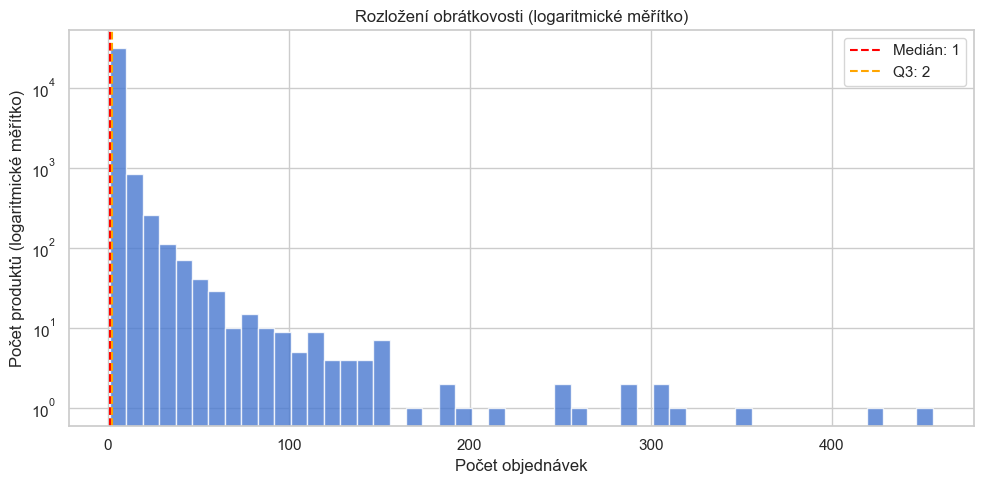

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(turnover_data, bins=50, edgecolor="white", alpha=0.8)
ax.set_xlabel("Počet objednávek")
ax.set_ylabel("Počet produktů (logaritmické měřítko)")
ax.set_title("Rozložení obrátkovosti (logaritmické měřítko)")
ax.set_yscale("log")
ax.axvline(turnover_data.median(), color="red", linestyle="--", label=f"Medián: {turnover_data.median():.0f}")
ax.axvline(turnover_data.quantile(0.75), color="orange", linestyle="--", label=f"Q3: {turnover_data.quantile(0.75):.0f}")
ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/eda_turnover_log_distribution.png", bbox_inches="tight")
plt.show()

## 6. Korelační matice numerických proměnných

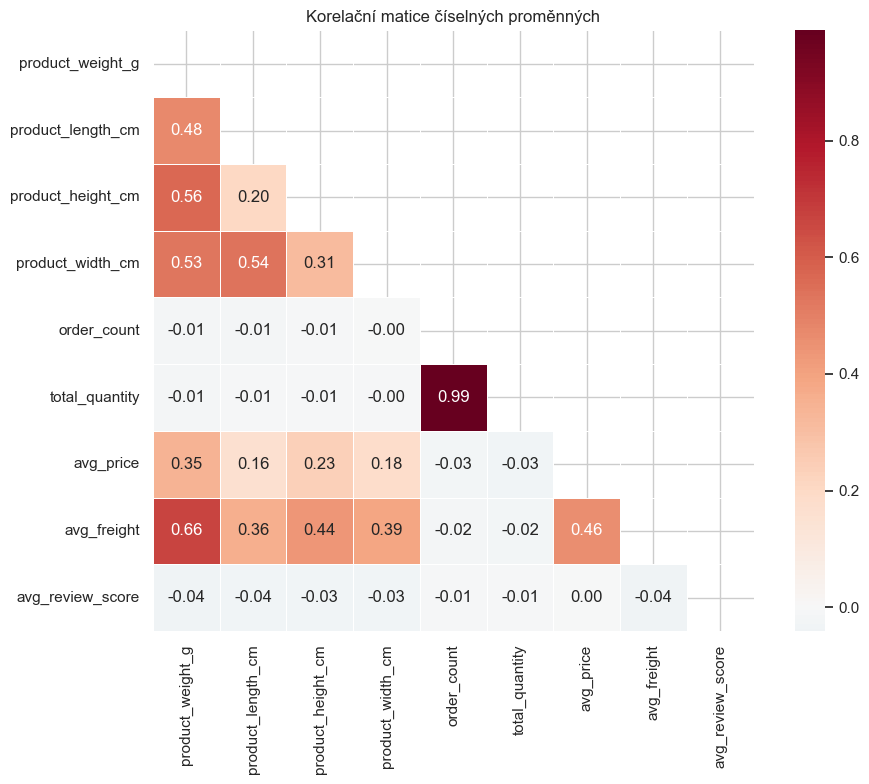

In [13]:
numeric_cols = ["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm",
                "order_count", "total_quantity", "avg_price", "avg_freight", "avg_review_score"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Korelační matice číselných proměnných")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/eda_correlation_matrix.png", bbox_inches="tight")
plt.show()

## 7. Hmotnost vs. objem

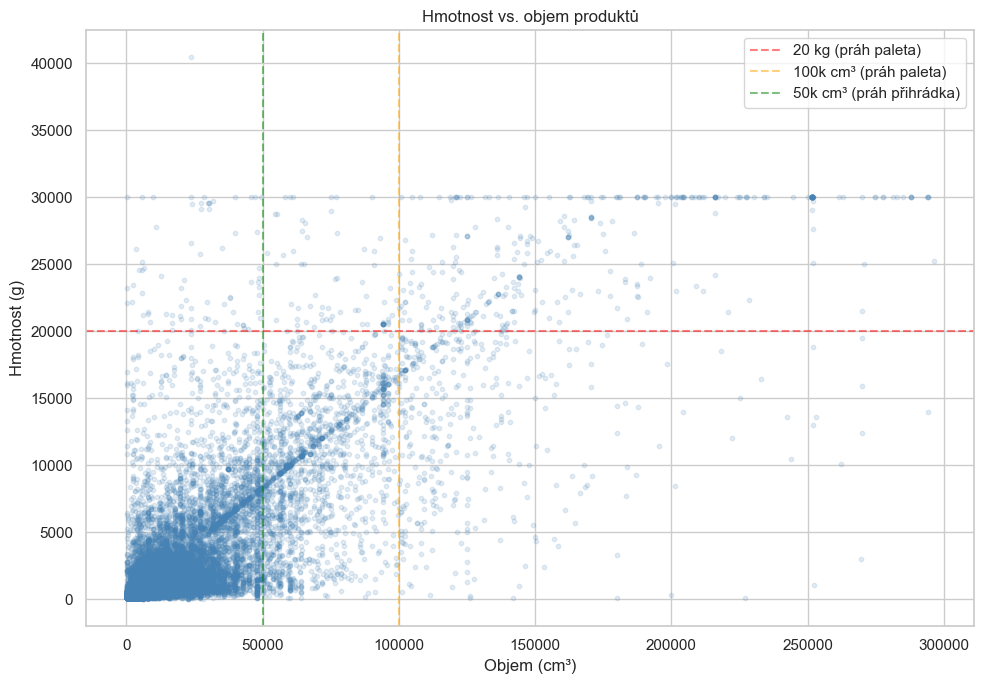

Objem — Min: 168, Medián: 6840, Max: 296208


In [14]:
df["volume_cm3"] = df["product_length_cm"] * df["product_height_cm"] * df["product_width_cm"]

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    df["volume_cm3"], df["product_weight_g"],
    alpha=0.15, s=10, c="steelblue",
)
ax.set_xlabel("Objem (cm³)")
ax.set_ylabel("Hmotnost (g)")
ax.set_title("Hmotnost vs. objem produktů")

ax.axhline(20000, color="red", linestyle="--", alpha=0.5, label="20 kg (práh paleta)")
ax.axvline(100000, color="orange", linestyle="--", alpha=0.5, label="100k cm³ (práh paleta)")
ax.axvline(50000, color="green", linestyle="--", alpha=0.5, label="50k cm³ (práh přihrádka)")
ax.legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/eda_weight_vs_volume.png", bbox_inches="tight")
plt.show()

print(f"Objem — Min: {df['volume_cm3'].min():.0f}, Medián: {df['volume_cm3'].median():.0f}, Max: {df['volume_cm3'].max():.0f}")

## 8. Review score distribuce (pouze EDA)
> **Poznámka:** Review score se NESMÍ použít jako feature pro model (data leakage — vzniká až po doručení).

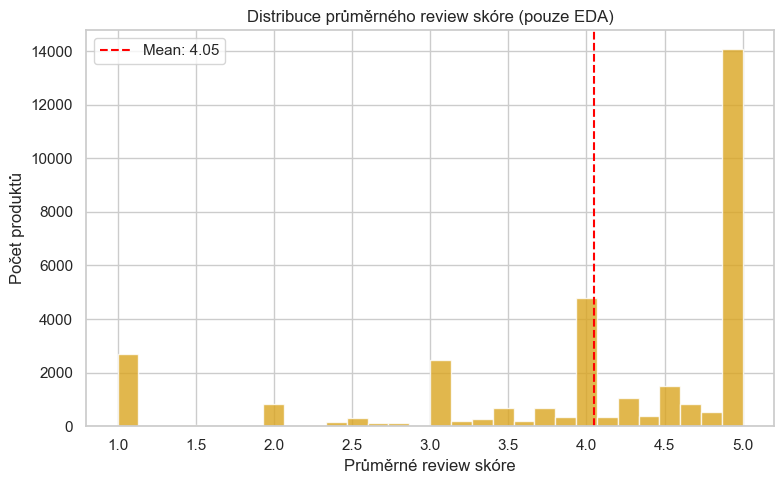

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
review_data = df["avg_review_score"].dropna()
ax.hist(review_data, bins=30, edgecolor="white", alpha=0.8, color="goldenrod")
ax.set_xlabel("Průměrné review skóre")
ax.set_ylabel("Počet produktů")
ax.set_title("Distribuce průměrného review skóre (pouze EDA)")
ax.axvline(review_data.mean(), color="red", linestyle="--", label=f"Mean: {review_data.mean():.2f}")
ax.legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/eda_review_distribution.png", bbox_inches="tight")
plt.show()

## 9. Shrnutí Fáze 1

In [16]:
print("SHRNUTÍ FÁZE 1: Načtení a propojení dat")
print("=" * 60)
print(f"Celkem produktů:              {len(df):,}")
print(f"Počet kategorií:              {df['product_category_name_english'].nunique()}")
print(f"Delivered objednávek:         {len(orders):,} z {len(orders_raw):,}")
print(f"Produktů s obrátkovostí:      {df['order_count'].notna().sum():,}")
print(f"Produktů s review skóre:      {df['avg_review_score'].notna().sum():,}")
print(f"Sloupce: {df.columns.tolist()}")
print(f"\nVýstup uložen: data/processed/products_clean.csv")

SHRNUTÍ FÁZE 1: Načtení a propojení dat
Celkem produktů:              32,951
Počet kategorií:              74
Delivered objednávek:         96,478 z 99,441
Produktů s obrátkovostí:      32,216
Produktů s review skóre:      32,789
Sloupce: ['product_id', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'order_count', 'total_quantity', 'avg_price', 'avg_freight', 'first_order_date', 'last_order_date', 'avg_review_score', 'volume_cm3']

Výstup uložen: data/processed/products_clean.csv
